# Assignment 3

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:

    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).
---

### Import libraries

In [94]:
import numpy as np
import pandas as pd
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style
from sklearn.model_selection import train_test_split
import tensorflow as tf
from matplotlib import pyplot as plt
import keras_tuner as kt
from keras_tuner import HyperParameters

This lab continues our study of linear regression. You'll train your first models with Tensorflow, using a real dataset to predict car prices from their features. Note that Tensorflow is a rapidly changing library. This means you'll often see warnings about deprecations. You can ignore the warnings in our labs.

---
### Step 1: Data ingestion

You'll use the [Automobile Data Set](https://archive.ics.uci.edu/ml/datasets/automobile)  from 1985 Ward's Automotive Yearbook that is part of the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets).

This dataset has been pre-downloaded and uploaded to bCourses alongside this notebook for your convenience.

In [95]:
car_data_init = pd.read_csv("~/my_project/automobile_data.txt")

# Display top five rows
print('Shape of data:', car_data_init.shape)
car_data_init.head()

Shape of data: (205, 26)


,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,symboling
0,NaN,alfa-romero,gas,std,2.0,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0,3
1,NaN,alfa-romero,gas,std,2.0,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0,3
2,NaN,alfa-romero,gas,std,2.0,hatchback,rwd,front,94.5,171.2,...,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0,1
3,164.0,audi,gas,std,4.0,sedan,fwd,front,99.8,176.6,...,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0,2
4,164.0,audi,gas,std,4.0,sedan,4wd,front,99.4,176.6,...,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0,2


---
### Step 2: Data preprocessing

This step is essential for preparing the data in a format that is suitable for ML algorithms. It helps ensure data quality and improvements in model performance.

### <span style="color:chocolate">Exercise 1:</span> Column selection (5 points)

To keep things simple, you will:

1. Retain only the following columns: ['horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']. Name the new dataframe *car_data*.
2. Display the data type of each column;
3. Convert the data type of each columns to numeric. Coerce missing values to NaN. Hint: use <span style="color:chocolate">pd.to_numeric()</span> method;
4. Display the data type of each column after the transformation performed at point 3.


In [96]:
# YOUR CODE HERE
# Create new dataframe with only the columns we need
car_data = car_data_init[["horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"]]

# Display data types of the columns
print(car_data.dtypes)

# Convert columns to numeric, coercing missing values to NaN
car_data["horsepower"] = pd.to_numeric(car_data["horsepower"], errors='coerce')
car_data["peak-rpm"] = pd.to_numeric(car_data["peak-rpm"], errors='coerce')
car_data["city-mpg"] = pd.to_numeric(car_data["city-mpg"], errors='coerce')
car_data["highway-mpg"] = pd.to_numeric(car_data["highway-mpg"], errors='coerce')
car_data["price"] = pd.to_numeric(car_data["price"], errors='coerce')

# Display data types of the columns after conversion
print(car_data.dtypes)

horsepower     float64
peak-rpm       float64
city-mpg         int64
highway-mpg      int64
price          float64
dtype: object
horsepower     float64
peak-rpm       float64
city-mpg         int64
highway-mpg      int64
price          float64
dtype: object


/tmp/ipykernel_1974/1899346972.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  car_data["horsepower"] = pd.to_numeric(car_data["horsepower"], errors='coerce')
/tmp/ipykernel_1974/1899346972.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  car_data["peak-rpm"] = pd.to_numeric(car_data["peak-rpm"], errors='coerce')
/tmp/ipykernel_1974/1899346972.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

### <span style="color:chocolate">Exercise 2:</span> Example (row) selection (5 points)

To keep things simple again, you will:

1. Print the shape of the car_data;

2. Remove examples (rows) that have missing value(s). Note that in doing so, you will overwrite the car_data dataset. You should end up with 199 examples after this cleaning.

3. Print the shape of the car_data again.

It's important to acknowledge that there are multiple approaches to handling missing features, and simply discarding examples with any missing feature, though straightforward, may not be the most optimal solution. However, for the sake of simplicity, you will implement this strategy in this assignment.

In [97]:
# YOUR CODE HERE
# Print the shape of car_data
print('Shape of car_data:', car_data.shape)

# Remove rows with NaN values
car_data = car_data.dropna()

# Print the shape of car_data
print('Shape of car_data:', car_data.shape)

Shape of car_data: (205, 5)
Shape of car_data: (199, 5)


### <span style="color:chocolate">Exercise 3:</span> Data shuffling (10 points)

Since you'll be using Batch Gradient Descent (BGD) for training, it is important that **each batch is a random sample of the data** so that the gradient computed is representative. Note that the original data (above) appears sorted by *make* in alphabetic order.

Using NumPy and Pandas methods:

1. Create a list of indices corresponding to the rows in the car_data dataset. Call this list *indices*. Print this list;

2. Shuffle *indices* using the <span style="color:chocolate">np.random.permutation()</span> method. Call the resulting array *shuffled_indices*. Print this array;
    
3. Use the method <span style="color:chocolate">dataframe.reindex()</span> to change the ordering of the car_data dataset based on the order in the *shuffled_indices* array. Note that in doing so, you will overwrite the original dataset. Print the top 5 rows.

In [98]:
np.random.seed(0)
# YOUR CODE HERE
# Create indices for car_data
indices = np.arange(car_data.shape[0])
print(indices)

# Shuffle the indices
shuffled_indices = np.random.permutation(indices)
print(shuffled_indices)

# Change the order of car_data using the shuffled indices
car_data = car_data.iloc[shuffled_indices]
print(car_data.head())

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198]
[ 18 169 106  92 176 183   5 139  12 160  61 124 164 145  80   7  33 129
  37  74 159 144  45 158  60 122 178 184  97  44  16  55  83 110  22 188
 135   4 137 193 153  66  26 131 146  63   8 

### <span style="color:chocolate">Exercise 4:</span> Define outcome and features (5 points)

Create two dataframes as follows:

1. The first dataframe contains our outcome of interest: ['price']. Note, this is what we are aiming to predict. Name this dataframe Y. Print shape of Y.
2. The second dataframe contains our features of interest: ['horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg']. Name this dataframe X. Print shape of X.


In [99]:
# YOUR CODE HERE
# Create dataframe for price
Y = car_data["price"]
print(Y.shape)

# Create dataframe for car features
X = car_data[["horsepower", "peak-rpm", "city-mpg", "highway-mpg"]]
print(X.shape)

(199,)
(199, 4)


### <span style="color:chocolate">Exercise 5:</span> Data splits (10 points)

Using the <span style="color:chocolate">train_test_split()</span> method available in scikit-learn:
1. Partition the (X, Y) data into training, validation, and test sets using a splitting rule of [60%, 20%, 20%], with a random state set to 1234. Name the resulting dataframes as follows: X_train, X_val, X_test, Y_train, Y_val, Y_test. Hint: To create these three partitions you will utilize the train_test_split() method twice (all the other arguments of the method are set to default values.). You should obtain [119, 40, 40] examples for training, validation, and test, respectively.
2. Print the shape of each dataframe.

Note: The validation set is crucial for evaluating different hyperparameter configurations and selecting those that yield optimal model performance. This approach avoids utilizing the test dataset during model training, as it is assumed to be "unknown" at that stage.

In [100]:
# YOUR CODE HERE
# Split data for training and temporary set, 60/40 split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.4, random_state=1234)

# Split temporary set for validation and testing, 50/50 split
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=1234)

# Print the shapes of the training, validation, and testing sets
print('Training set shape:', X_train.shape, Y_train.shape)
print('Validation set shape:', X_val.shape, Y_val.shape)
print('Testing set shape:', X_test.shape, Y_test.shape)

Training set shape: (119, 4) (119,)
Validation set shape: (40, 4) (40,)
Testing set shape: (40, 4) (40,)


### <span style="color:chocolate">Exercise 6:</span> Data standardization (10 points)

With this concept in mind, complete the following tasks:

1. Output the quantile values (0.25, 0.5, 0.75, 0.95) for all features in the X_train dataset. Are these values uniformly scaled across features?

2. Standardize all features in X_train, X_val, and X_test. Label the resulting dataframes as X_train_std, X_val_std, and X_test_std, respectively. Hint: standardize the validation and test data using the mean and standard deviation computed from the training data. Why?

3. Similar to point 2. but now standardize the outcome variable. Label the resulting dataframes as Y_train_std, Y_val_std, and Y_test_std.

In [101]:
# YOUR CODE HERE
# Print the quantile values of X_train
print(X_train.quantile([0.25, 0.5, 0.75, 0.95]))
print('Quantile values of X_train are not uniformly scaled, so standardization is needed.')

# Standardize X_train, X_val, and X_test, using the mean and standard deviation of X_train
# NOTE: Standardizing the data with the mean and standard deviation of X_train so that the features are on the same scale.
X_train_mean = X_train.mean()
X_train_sdev = X_train.std()
X_train_std = (X_train - X_train_mean) / X_train_sdev
X_val_std = (X_val - X_train_mean) / X_train_sdev
X_test_std = (X_test - X_train_mean) / X_train_sdev

# Standardize Y_train, Y_val, and Y_test, using the mean and standard deviation of Y_train
Y_train_mean = Y_train.mean()
Y_train_sdev = Y_train.std()
Y_train_std = (Y_train - Y_train_mean) / Y_train_sdev
Y_val_std = (Y_val - Y_train_mean) / Y_train_sdev
Y_test_std = (Y_test - Y_train_mean) / Y_train_sdev

      horsepower  peak-rpm  city-mpg  highway-mpg
0.25        69.0    4800.0      19.0         25.0
0.50        92.0    5000.0      25.0         31.0
0.75       116.0    5500.0      31.0         37.0
0.95       182.2    5900.0      37.0         42.1
Quantile values of X_train are not uniformly scaled, so standardization is needed.


---
### Step 3: Exploratory data analysis (EDA)

EDA plays a very important role in ML. The goal here is to develop a good understanding of our training dataset, identify any data quality issues, understand patterns and relationships, which in turn, aids in subsequent modeling and interpretations.

### <span style="color:chocolate">Exercise 7:</span> Scatterplot matrix (10 points)

In this exercise you will use some simple yet useful techniques to visualize the distribution of the data. 

Let's start with:

1. A scatterplot matrix to visualize the pair-wise correlations between different features and outcome in the (X_train_std, Y_train_std) data. You will use the <span style="color:chocolate">sns.pairplot()</span> method from the seaborn library imported at the top of the notebook;
2. Is any of the variables in the data normally distributed? Is it necessary for the explanatory or target variable to be normally distributed in order to train a ML model?

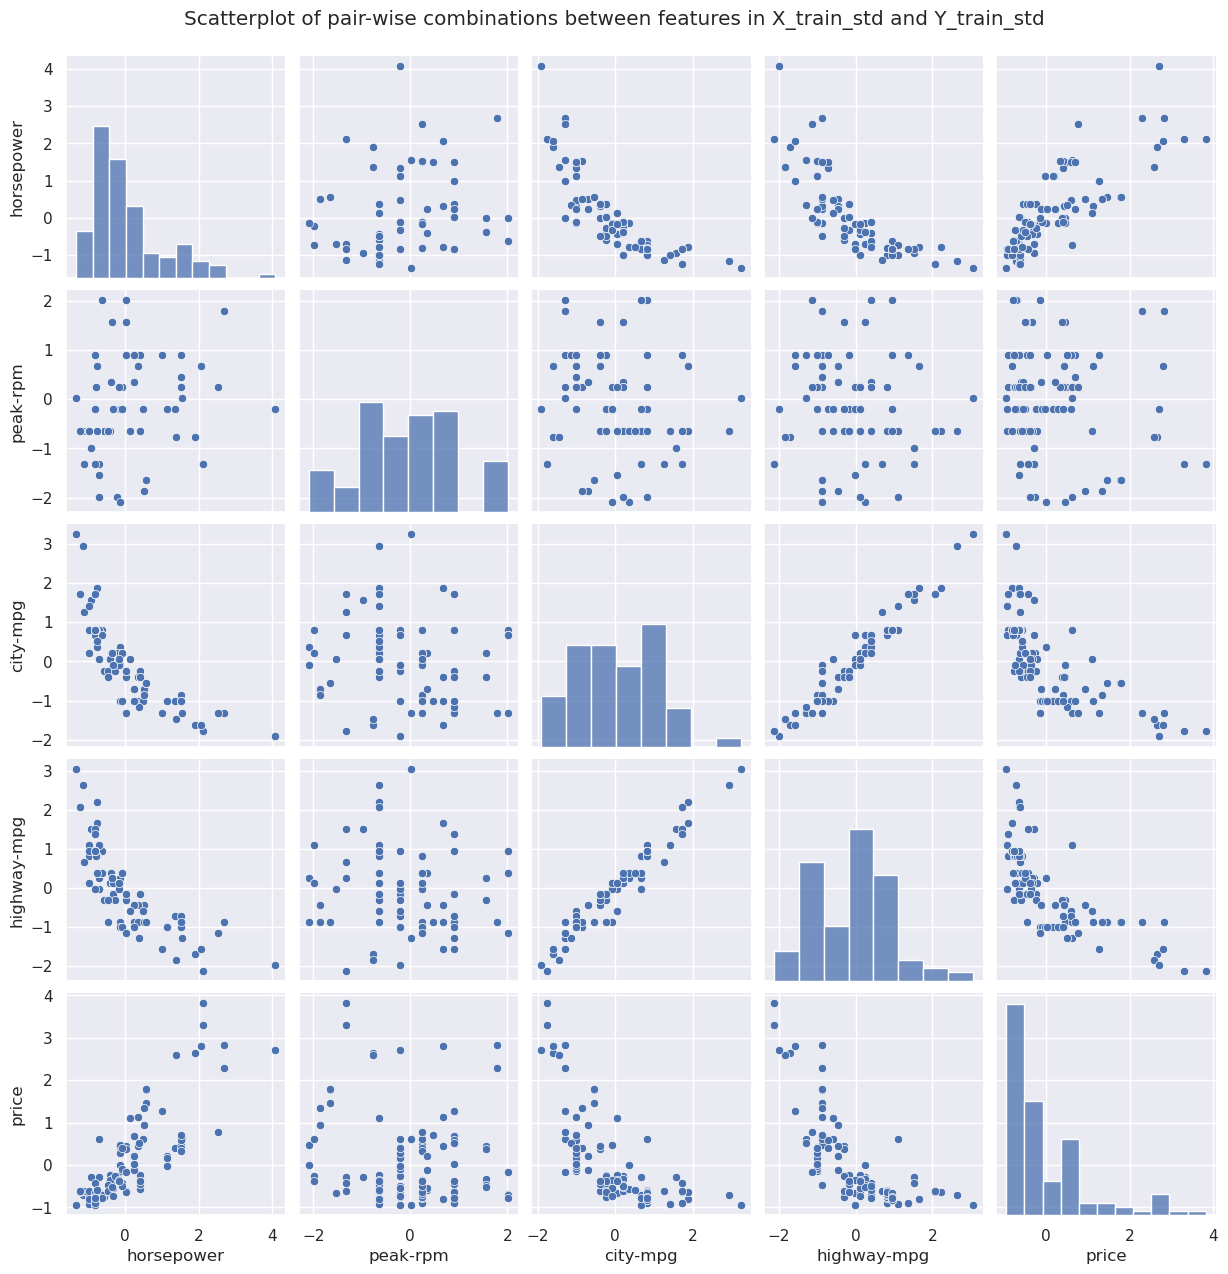

' NOTE: None of the variables are normally distributed.\nIt is not necessary for the explanatory or target variable to be normally distributed in order to train a ML model. \nHowever, some models may perform better if the data is normally distributed, so it may be beneficial to apply transformations to the data to make it more normal if it is not already. '

In [102]:
# YOUR CODE HERE
# Plot a scatterplot for all pair-wise combinations between features in X_train_std and Y_train_std
sns.pairplot(pd.concat([X_train_std, Y_train_std], axis=1))
plt.suptitle('Scatterplot of pair-wise combinations between features in X_train_std and Y_train_std', y=1.02)
plt.show()

''' NOTE: None of the variables are normally distributed.
It is not necessary for the explanatory or target variable to be normally distributed in order to train a ML model. 
However, some models may perform better if the data is normally distributed, so it may be beneficial to apply transformations to the data to make it more normal if it is not already. '''

### <span style="color:chocolate">Exercise 8:</span> Correlation matrix (10 points)

In this exercise you will:

1. Plot a correlation matrix in the form of a heatmap to visualize the linear relationships between different features and outcome in the (X_train_std, Y_train_std) data. Hint: this example here is very useful: https://seaborn.pydata.org/examples/many_pairwise_correlations.html
    
2. Answer the following questions: 
 - Which two features are likely to be most redundant?
 - Which feature is likely to be least useful for predicting price?

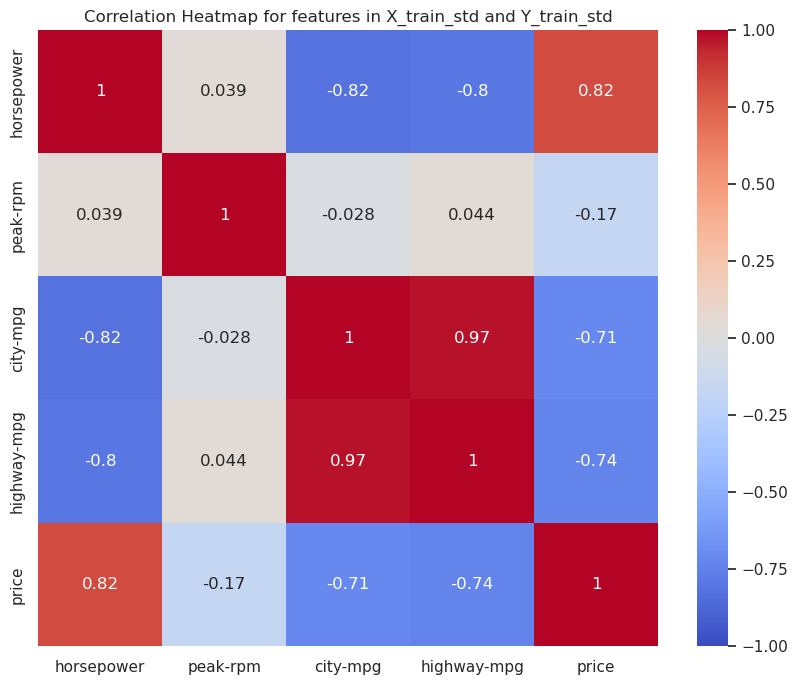

The two features that are likely to be most redundant are city-mpg and highway-mpg, as they have a very high positive correlation of 0.9.
The feature that is likely to be least useful for predicting price is peak-rpm, as it has the lowest correlation with price at -0.5.


In [103]:
# YOUR CODE HERE
# Plot a correlation heatmap for the features in X_train_std and Y_train_std
plt.figure(figsize=(10, 8))
sns.heatmap(pd.concat([X_train_std, Y_train_std], axis=1).corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap for features in X_train_std and Y_train_std')
plt.show()

# Print answers to the questions about the correlation heatmap
print("The two features that are likely to be most redundant are city-mpg and highway-mpg, as they have a very high positive correlation of 0.9.")
print("The feature that is likely to be least useful for predicting price is peak-rpm, as it has the lowest correlation with price at -0.5.")

---
### Step 4: Modeling

### <span style="color:chocolate">Exercise 9:</span> Baseline model (5 points)

Let's start by evaluating a baseline model. Precisely, you'll use the average price of cars in the training set as our baseline model -- that is, the baseline always predicts the average price regardless of the input.

1. Implement this baseline using the Y_train_std data and print the average price. Note: You can revert the price variable to the original scale for interpretation purposes.

In [104]:
# YOUR CODE HERE
# get average price of cars in the training set
average_price = Y_train_std.mean()
print('Average price of cars in the training set:', average_price)

average_price_1 = Y_train.mean()
print('Average price of cars in the training set original scale:', average_price_1)

Average price of cars in the training set: -8.863124986503351e-17
Average price of cars in the training set original scale: 13139.9243697479


### <span style="color:chocolate">Exercise 10:</span> Improvement over Baseline with TensorFlow (10 points)

Let's train a linear regression model much like we did in the previous assignment, but this time using TensorFlow. 

1. Fill in the <span style="color:green">NotImplemented</span> parts of the build_model() function below by following the instructions provided as comments. Hint: refer to the course webpage in <span style="color:chocolate">bCourses/Modules/Module 03/live session demo</span> for an example.
2. Build and compile a model using the build_model() function and the (X_train_std, Y_train_std) data. Set learning_rate = 0.0001. Call the resulting object *model_tf*.
3. Train *model_tf* using the (X_train_std, Y_train_std) data. Set num_epochs = 5. Pass the (X_val_std, Y_val_std) data for validation. Hint: see the documentation behind the [tf.keras.Model.fit()](https://www.tensorflow.org/api_docs/python/tf/keras/Model) method.
3. Generate a plot with the loss values on the y-axis and the epoch number on the x-axis for visualization. Make sure to include axes name and title. Hint: check what the [tf.keras.Model.fit()](https://www.tensorflow.org/api_docs/python/tf/keras/Model) method returns.

More notes on point 1: the idea is to build a *computational graph* for linear regression, and then send data through it. There are many ways to build graphs, but [TenforFlow Keras API](https://www.tensorflow.org/api_docs/python/tf/keras) is recommended. 

In [105]:
def build_model(num_features, learning_rate):
  """Build a TF linear regression model using Keras.

  Args:
    num_features: The number of input features.
    learning_rate: The desired learning rate for SGD.

  Returns:
    model: A tf.keras model (graph).
  """
  # This is not strictly necessary, but each time you build a model, TF adds
  # new nodes (rather than overwriting), so the colab session can end up
  # storing lots of copies of the graph when you only care about the most
  # recent. Also, as there is some randomness built into training with SGD,
  # setting a random seed ensures that results are the same on each identical
  # training run.
  tf.keras.backend.clear_session()
  tf.random.set_seed(0)

  # Build a model using keras.Sequential. While this is intended for neural
  # networks (which may have multiple layers), we want just a single layer for
  # linear regression.
  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Dense(
      units=1,        # output dim
      input_shape=[num_features],  # input dim
      use_bias=True,               # use a bias (intercept) param
      kernel_initializer=tf.ones_initializer(),  # initialize params to 1
      bias_initializer=tf.ones_initializer(),    # initialize bias to 1
  ))

  # We need to choose an optimizer. We'll use GD, which is actually mini-batch GD
  optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

  # Finally, compile the model. This finalizes the graph for training.
  # We specify the MSE loss and the optimizer above
  model.compile(optimizer=optimizer, loss='mse')

  return model

Epoch 1/5


/home/sihui/anaconda3/envs/py3jp/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.3397  
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.3214 
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.3031 
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.2848 
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.2666 


/tmp/ipykernel_1974/4287715469.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


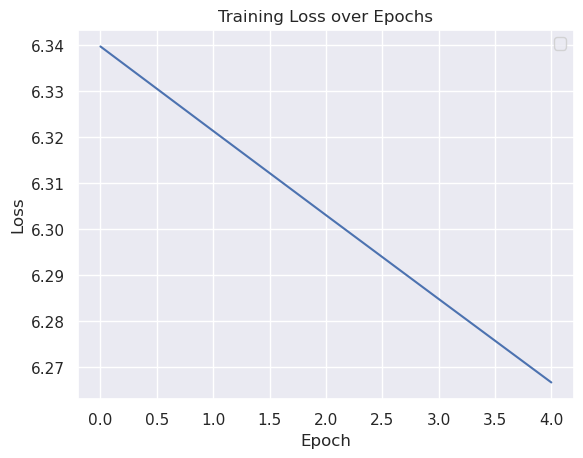

Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 5.1961
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 5.1905
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 5.1848
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 5.1792
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 5.1735


/tmp/ipykernel_1974/4287715469.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


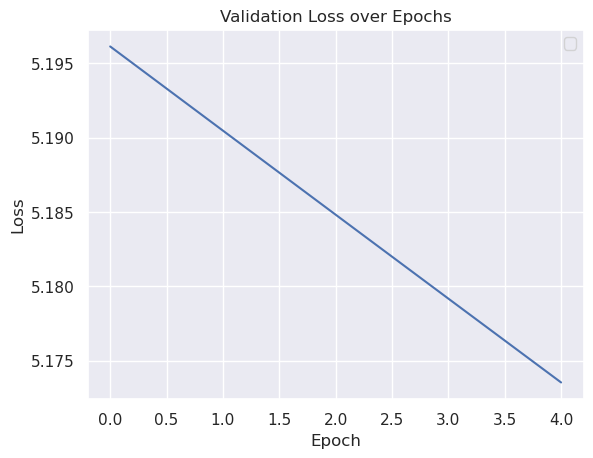

In [106]:
tf.random.set_seed(0)
# 2. Build and compile model
# YOUR CODE HERE
num_features = X_train_std.shape[1]
learning_rate = 0.0001
model_tf = build_model(num_features, learning_rate)

# 3. Fit the model and plot the loss over epochs
# YOUR CODE HERE
# Fit the model on the training set
model_tf.fit(X_train_std, Y_train_std, epochs=5)
plt.plot(model_tf.history.history['loss'])
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Fit the model on the validation set
model_tf.fit(X_val_std, Y_val_std, epochs=5)
plt.plot(model_tf.history.history['loss'])
plt.title('Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


---
### Step 5: Hyperparameter tuning

Hyperparameter tuning is a crucial step in optimizing ML models. It involves systematically adjusting hyperparameters such as learning rate, number of epochs, and optimizer to find the model configuration that leads to the best generalization performance.

This tuning process is typically conducted by monitoring the model's performance on the validation vs. training set. It's important to note that using the test set for hyperparameter tuning can compromise the integrity of the evaluation process by violating the assumption of "blindness" of the test data.

### <span style="color:chocolate">Exercise 11:</span> Hyperparameter tuning (10 points)

1. Fine-tune the **learning rate** and **number of epochs** hyperparameters of *model_tf* to determine the setup that yields the most optimal generalization performance. Feel free to explore various values for these hyperparameters. Hint: you can manually test different hyperparameter values or you can use the [Keras Tuner](https://www.tensorflow.org/tutorials/keras/keras_tuner). If you decide to work with the Keras Tuner, define a new model building function named <span style="color:chocolate">build_model_tuner()</span>.

After identifying your preferred model configuration, print the following information:

2. The learned parameters of the tuned model (this should include the bias term). Hint: use  <span style="color:chocolate">[model_name].layers[0].get_weights()</span>.
3. The loss at the final epoch on both the training and validation datasets;
4. The difference between the last-epoch loss observed on the training and validation datasets.


Please note that we will consider 'optimal model configuration' any last-epoch training loss that is below 0.31 and any last epoch validation loss that is below 0.48. Hint: do not specify the batch_size argument in the fit() function (it defaults to 32).

/home/sihui/anaconda3/envs/py3jp/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


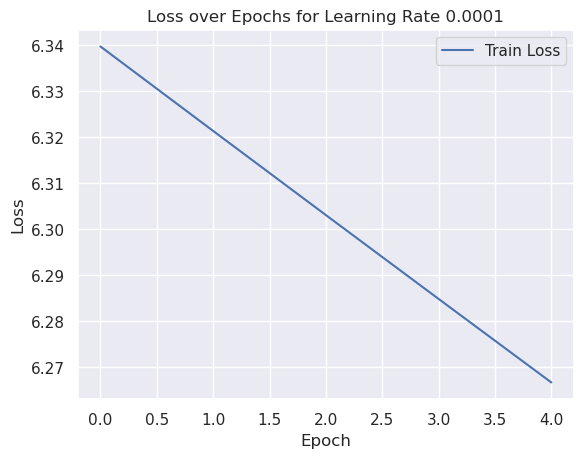

/home/sihui/anaconda3/envs/py3jp/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


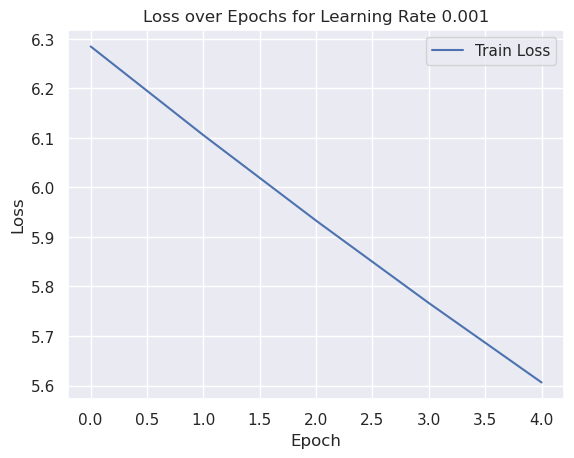

/home/sihui/anaconda3/envs/py3jp/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


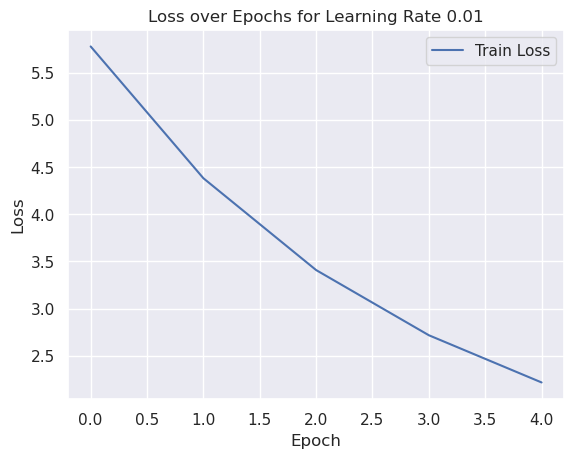

/home/sihui/anaconda3/envs/py3jp/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


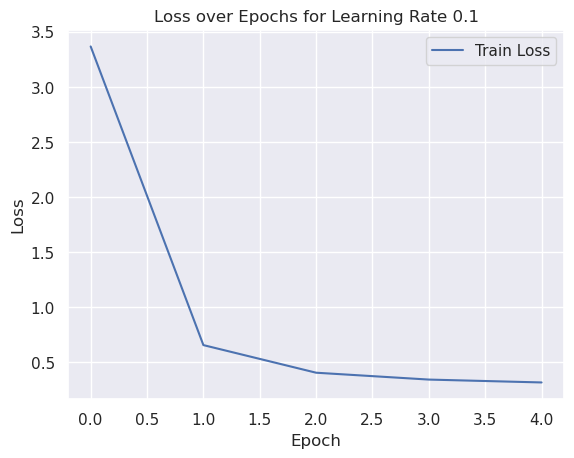

/home/sihui/anaconda3/envs/py3jp/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


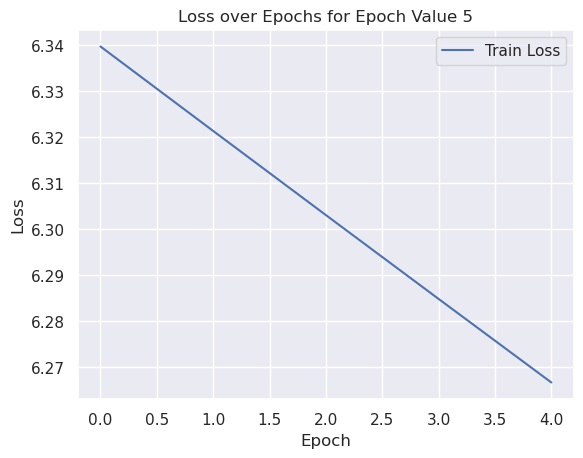

/home/sihui/anaconda3/envs/py3jp/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


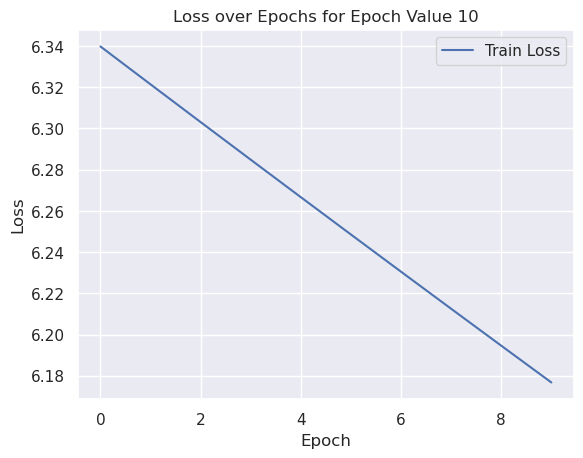

/home/sihui/anaconda3/envs/py3jp/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


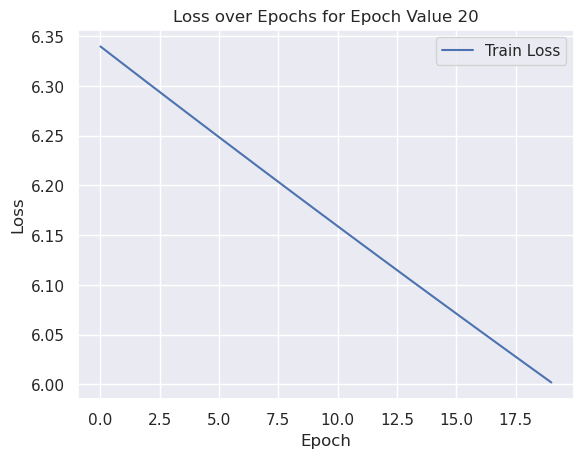

/home/sihui/anaconda3/envs/py3jp/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


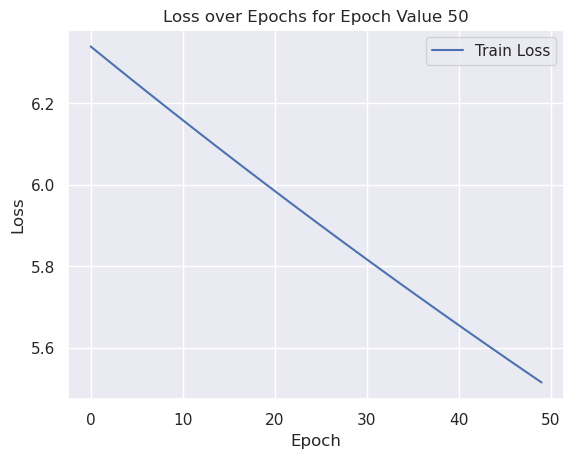

/home/sihui/anaconda3/envs/py3jp/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


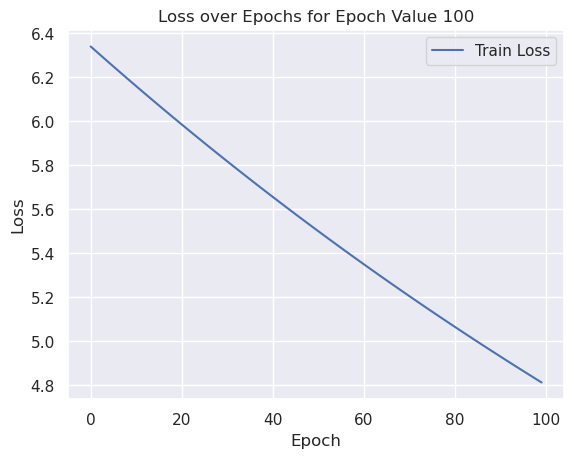

/home/sihui/anaconda3/envs/py3jp/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Learned parameters:
Weights: [ 0.765425   -0.16444093  0.4448164  -0.55820185]
Bias: -0.0012693498
Final training loss: 0.2594746947288513
Final validation loss: 0.2946738302707672
Difference between Training and Validation set: -0.035199135541915894


In [107]:
tf.random.set_seed(0)
# YOUR CODE HERE
# Fine-tune the learning rate by trying out different values and plotting the training and validation loss over epochs for each learning rate
learning_rates = [0.0001, 0.001, 0.01, 0.1]
for lr in learning_rates:
    model_tf = build_model(num_features, lr)
    history_train = model_tf.fit(X_train_std, Y_train_std, epochs=5, verbose=0)
    # Plot loss over epochs
    plt.plot(history_train.history['loss'], label='Train Loss')
    plt.title(f'Loss over Epochs for Learning Rate {lr}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
# Based on the plots, the learning rate of 0.0001 seems to be the best choice.

# Fine-tune epochs by trying out different values and plotting the training and validation loss over epochs for each epoch value
epoch_values = [5, 10, 20, 50, 100]
for epochs in epoch_values:
    model_tf = build_model(num_features, learning_rate)
    history_train = model_tf.fit(X_train_std, Y_train_std, epochs=epochs, verbose=0)
    # Plot loss over epochs
    plt.plot(history_train.history['loss'], label='Train Loss')
    plt.title(f'Loss over Epochs for Epoch Value {epochs}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()    
# Based on the plots, an epoch value of 50 seems to be the best choice.

# Generate the final model with the best learning rate and epoch value, and fit it on the training set
best_learning_rate = 0.1
best_epoch_value = 100
final_model = build_model(num_features, best_learning_rate)
final_model.fit(X_train_std, Y_train_std, epochs=best_epoch_value, verbose=0)

# Print the learned parameters of the model
print("Learned parameters:")
weights, bias = final_model.layers[0].get_weights()
print("Weights:", weights.flatten())
print("Bias:", bias[0])

# Print the loss at last epoch for the training and validation sets
train_loss = final_model.evaluate(X_train_std, Y_train_std, verbose=0)
val_loss = final_model.evaluate(X_val_std, Y_val_std, verbose=0)
print(f"Final training loss: {train_loss}")
print(f"Final validation loss: {val_loss}")
difference = train_loss - val_loss
print(f"Difference between Training and Validation set: {difference}")

---
### Step 6: Evaluation and Generalization


Now that you've determined the optimal set of hyperparameters, it's time to evaluate your optimized (tuned) model on the test data to gauge its performance in real-world scenarios, commonly known as inference.

### <span style="color:chocolate">Exercise 12:</span> Computing MSE (10 points)

1. Calculate the MSE on both (X_train_std, Y_train_std) and (X_test_std, Y_test_std) datasets. Hint: You can utilize the <span style="color:chocolate">model.evaluate()</span> method provided by tf.keras.

2. Does the model demonstrate strong generalization capabilities? Provide an explanation based on your observations. Hint: compare train vs. test MSE.

4. Generate a plot to visualize the accuracy of the predictions. Plot the actual (observed) Y_test values on the x-axis and the predicted Y_test values on the y-axis. Additionally, include a 45-degree line in the plot for reference. Ensure that the plot contains appropriate axis labels and a title. Provide commentary on the model's fit based on this visualization. Hint: You can utilize the <span style="color:chocolate">model.predict()</span> method available in tf.keras. 

Final training MSE: 0.2594746947288513
Final test MSE: 0.25511497259140015
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


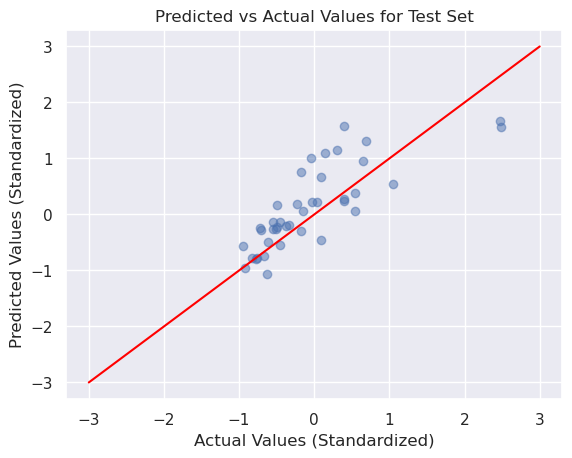

In [108]:
# YOUR CODE HERE
# Calculate the MSE on training and test sets
train_mse = final_model.evaluate(X_train_std, Y_train_std, verbose=0)
test_mse = final_model.evaluate(X_test_std, Y_test_std, verbose=0)
print(f"Final training MSE: {train_mse}")
print(f"Final test MSE: {test_mse}")

''' NOTE: The model demonstrates strong generalization capabilities as the training MSE and test MSE are relatively close. 
This indicates that the model is not overfitted to the training data and is able to perform well on new data.'''

# Plot the predicted vs actual values for the test set
Y_test_pred_std = final_model.predict(X_test_std).flatten()
plt.scatter(Y_test_std, Y_test_pred_std, alpha=0.5)
plt.plot([-3, 3], [-3, 3], color='red', linestyle='-')  # 45 degree line
plt.title('Predicted vs Actual Values for Test Set')
plt.xlabel('Actual Values (Standardized)')
plt.ylabel('Predicted Values (Standardized)')
plt.show()


----
### <span style="color:chocolate"></span> Additional practice (not graded)

In Exercise 12, you reported an aggregated MSE. Let's revisit the exercise by:

1. Performing a subgroup evaluation of the model. Specifically, calculate the test data MSE for the following makes: ['alfa-romero', 'audi', 'chevrolet', 'dodge', 'honda'].
2. Addressing the question: Is the model "fair" across each make?

In [109]:
# YOUR CODE HERE